In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.ticker as ticker
import torchvision

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


class CNN_Model(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = torch.nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = torch.nn.GroupNorm(8, 32)
        self.act1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2)

        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = torch.nn.GroupNorm(8, 64) 
        self.act2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2)

        self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = torch.nn.GroupNorm(8, 128) 
        self.act3 = torch.nn.ReLU()
        self.pool3 = torch.nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = torch.nn.Linear(128, 100)
        self.act4 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(100, 10)

    def forward(self, x):
        y = self.act1(self.bn1(self.conv1(x)))
        y = self.pool1(y)

        y = self.act2(self.bn2(self.conv2(y)))
        y = self.pool2(y)

        y = self.act3(self.bn3(self.conv3(y)))
        y = self.pool3(y)

        y = torch.flatten(y, 1)
        y = self.act4(self.fc1(y))
        y = self.fc2(y)
        return y     

In [4]:
set_seed(42)
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 0)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 0)

LEARNING_RATE = 0.001
EPOCHS = 500

# GD

In [5]:
set_seed(42)
class GD(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def calc_full_grads(self, model, dataloader, loss_func):
        model.train()
        self.zero_grad()
        train_loss, correct, total = 0, 0, 0
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = loss_func(Y, T) * len(X)

            loss.backward()

            train_loss += loss.item()
            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += len(X)
        
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue
                    p.grad.div_(total)
                
        train_loss /= total
        train_acc = correct / total

        return train_loss, train_acc


    @torch.no_grad()
    def step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                p.sub_(p.grad, alpha = lr)

        return loss

In [13]:
set_seed(42)
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = GD(model.parameters(), lr = LEARNING_RATE)

GD_train_loss_history = []
GD_test_loss_history = []
GD_train_acc_history = []
GD_test_acc_history = []

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()

    train_loss, train_acc = optimizer.calc_full_grads(model, train_loader, criterion)
    optimizer.step()

    GD_train_loss_history.append(train_loss)
    GD_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, T in test_loader:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

    test_loss /= len(test_loader)
    test_acc = correct / total

    GD_test_loss_history.append(test_loss)
    GD_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

epoch: 1
Train Loss: 2.3201, Acc: 0.0986 | Test Loss: 2.3197, Acc: 0.0986
epoch: 2
Train Loss: 2.3199, Acc: 0.0986 | Test Loss: 2.3196, Acc: 0.0987
epoch: 3
Train Loss: 2.3197, Acc: 0.0987 | Test Loss: 2.3194, Acc: 0.0988
epoch: 4
Train Loss: 2.3195, Acc: 0.0987 | Test Loss: 2.3192, Acc: 0.0988
epoch: 5
Train Loss: 2.3194, Acc: 0.0987 | Test Loss: 2.3190, Acc: 0.0989
epoch: 6
Train Loss: 2.3192, Acc: 0.0988 | Test Loss: 2.3188, Acc: 0.0991
epoch: 7
Train Loss: 2.3190, Acc: 0.0988 | Test Loss: 2.3186, Acc: 0.0992
epoch: 8
Train Loss: 2.3188, Acc: 0.0988 | Test Loss: 2.3184, Acc: 0.0992
epoch: 9
Train Loss: 2.3186, Acc: 0.0989 | Test Loss: 2.3183, Acc: 0.0992
epoch: 10
Train Loss: 2.3184, Acc: 0.0989 | Test Loss: 2.3181, Acc: 0.0993
epoch: 11
Train Loss: 2.3183, Acc: 0.0989 | Test Loss: 2.3179, Acc: 0.0993
epoch: 12
Train Loss: 2.3181, Acc: 0.0989 | Test Loss: 2.3177, Acc: 0.0993
epoch: 13
Train Loss: 2.3179, Acc: 0.0990 | Test Loss: 2.3176, Acc: 0.0993
epoch: 14
Train Loss: 2.3177, Acc:

# SGD

In [7]:
set_seed(42)
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = LEARNING_RATE)

SGD_train_loss_history = []
SGD_test_loss_history = []
SGD_train_acc_history = []
SGD_test_acc_history = []

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0
    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    train_loss /= len(train_loader)
    train_acc = correct / total

    SGD_train_loss_history.append(train_loss)
    SGD_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    test_loss /= len(test_loader)
    test_acc = correct / total

    SGD_test_loss_history.append(test_loss)
    SGD_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

epoch: 1


100%|██████████| 157/157 [00:01<00:00, 155.11it/s, loss=2.25, acc=0.207]


Train Loss: 2.2909, Acc: 0.1487 | Test Loss: 2.2686, Acc: 0.2069
epoch: 2


100%|██████████| 157/157 [00:01<00:00, 152.24it/s, loss=2.13, acc=0.21] 


Train Loss: 2.2345, Acc: 0.2065 | Test Loss: 2.1885, Acc: 0.2101
epoch: 3


...

Train Loss: 0.3547, Acc: 0.8768 | Test Loss: 0.9062, Acc: 0.7124
epoch: 499


100%|██████████| 157/157 [00:01<00:00, 156.61it/s, loss=0.747, acc=0.673]


Train Loss: 0.3541, Acc: 0.8777 | Test Loss: 1.0645, Acc: 0.6731
epoch: 500


100%|██████████| 157/157 [00:01<00:00, 156.40it/s, loss=0.63, acc=0.728] 

Train Loss: 0.3553, Acc: 0.8784 | Test Loss: 0.8766, Acc: 0.7282


# SVRG

In [8]:
set_seed(42)
class SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state["z"] = torch.zeros_like(p)
                state['hat_w'] = torch.clone(p)

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            loss = loss_func(Y, T) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue


                    grad = p.grad.detach()
                    state = self.state[p]
                    state["z"].add_(grad)

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["z"].div_(total_data)


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_w"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["w"])
                    if p.grad is None:
                        continue
                    state["snapshot_grad"] = torch.clone(p.grad.detach())


    @torch.no_grad()
    def step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                z = state['z']
                snapshot_grad = state["snapshot_grad"]
                v = grad - snapshot_grad + z
                p.sub_(v, alpha = lr)

        return loss

In [9]:
set_seed(42)
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = SVRG(model.parameters(), lr = LEARNING_RATE)

SVRG_train_loss_history = []
SVRG_test_loss_history = []
SVRG_train_acc_history = []
SVRG_test_acc_history = []

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.calc_full_grads(model, train_loader, criterion)

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.calc_snapshot_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    train_loss /= len(train_loader)
    train_acc = correct / total

    SVRG_train_loss_history.append(train_loss)
    SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    test_loss /= len(test_loader)
    test_acc = correct / total

    SVRG_test_loss_history.append(test_loss)
    SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

epoch: 1


100%|██████████| 157/157 [00:00<00:00, 159.09it/s, loss=2.25, acc=0.209]


Train Loss: 2.2912, Acc: 0.1505 | Test Loss: 2.2697, Acc: 0.2095
epoch: 2


100%|██████████| 157/157 [00:00<00:00, 157.42it/s, loss=2.13, acc=0.208]


Train Loss: 2.2359, Acc: 0.2081 | Test Loss: 2.1905, Acc: 0.2076
epoch: 3


...

100%|██████████| 157/157 [00:00<00:00, 165.77it/s, loss=1.36, acc=0.548]


Train Loss: 1.2564, Acc: 0.5482 | Test Loss: 1.2511, Acc: 0.5482
epoch: 36


100%|██████████| 157/157 [00:03<00:00, 50.87it/s, loss=1.48, acc=0.553] 


Train Loss: 1.2435, Acc: 0.5534 | Test Loss: 1.2516, Acc: 0.5534
epoch: 37


KeyboardInterrupt: 

# No Full Grad SVRG

In [ ]:
set_seed(42)
class NFG_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["hat_a"] = torch.zeros_like(p)
                    state['hat_w'] = torch.clone(p)

                state["a"].zero_()
                state["t"] = 0


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_w"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["snapshot_grad"] = torch.clone(p.grad.detach())
                    p.copy_(state["w"])


    def end_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                state["hat_a"].copy_(state["a"])
                state['hat_w'] = torch.clone(p).detach()


    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                a = state['a']
                hat_a = state["hat_a"]
                snapshot_grad = state["snapshot_grad"]
                t = state["t"]

                v = grad - snapshot_grad + hat_a
                p.sub_(v, alpha = lr)
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))

                state["t"] += 1

        return loss

In [ ]:
set_seed(42)
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

NFG_SVRG_train_loss_history = []
NFG_SVRG_test_loss_history = []
NFG_SVRG_train_acc_history = []
NFG_SVRG_test_acc_history = []

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.init_epoch()

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.calc_snapshot_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    optimizer.end_epoch()

    train_loss /= len(train_loader)
    train_acc = correct / total

    NFG_SVRG_train_loss_history.append(train_loss)
    NFG_SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    test_loss /= len(test_loader)
    test_acc = correct / total

    NFG_SVRG_test_loss_history.append(test_loss)
    NFG_SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

epoch: 1


100%|██████████| 157/157 [00:00<00:00, 160.38it/s, loss=2.25, acc=0.0986]


Train Loss: 2.3202, Acc: 0.0986 | Test Loss: 2.3199, Acc: 0.0986
epoch: 2


100%|██████████| 157/157 [00:00<00:00, 163.00it/s, loss=2.26, acc=0.212]


Train Loss: 2.2913, Acc: 0.1493 | Test Loss: 2.2697, Acc: 0.2117
epoch: 3


100%|██████████| 157/157 [00:00<00:00, 166.28it/s, loss=2.19, acc=0.224]


Train Loss: 2.2506, Acc: 0.2201 | Test Loss: 2.2252, Acc: 0.2243


# ASAI-SVRG

In [ ]:
set_seed(42)
class ASAI_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["hat_a"] = torch.zeros_like(p)
                    state["z"] = torch.clone(p.detach())
                    state["hat_z"] = torch.clone(p.detach())

                state["a"].zero_()
                state["z"].zero_()
                state["t"] = 0


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_z"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["snapshot_grad"] = torch.clone(p.grad.detach())
                    p.copy_(state["w"])


    def end_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                state["hat_a"].copy_(state["a"])
                state['hat_z'].copy_(state["z"])


    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                a = state['a']
                prev_a = state["hat_a"]
                prev_grad = state["snapshot_grad"]
                z = state["z"]
                t = state["t"]

                v = grad - prev_grad + prev_a
                p.sub_(v, alpha = lr)
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))
                z.mul_(t / (t+1)).add_(p, alpha = 1 / (t+1))

                state["t"] += 1

        return loss

In [ ]:
set_seed(42)
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = ASAI_SVRG(model.parameters(), lr = LEARNING_RATE)

ASAI_SVRG_train_loss_history = []
ASAI_SVRG_test_loss_history = []
ASAI_SVRG_train_acc_history = []
ASAI_SVRG_test_acc_history = []

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.init_epoch()

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.calc_snapshot_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    optimizer.end_epoch()

    train_loss /= len(train_loader)
    train_acc = correct / total

    ASAI_SVRG_train_loss_history.append(train_loss)
    ASAI_SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)

        backup = []
        with torch.no_grad():
            for group in optimizer.param_groups:
                for p in group['params']:
                    state = optimizer.state[p]
                    backup.append(p.clone())
                    p.copy_(state["z"])

        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        with torch.no_grad():
            i = 0
            for group in optimizer.param_groups:
                for p in group['params']:
                    p.copy_(backup[i])
                    i += 1

    test_loss /= len(test_loader)
    test_acc = correct / total

    ASAI_SVRG_test_loss_history.append(test_loss)
    ASAI_SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

epoch: 1


  0%|          | 0/782 [00:00<?, ?it/s]

100%|██████████| 157/157 [00:01<00:00, 156.85it/s, loss=2.25, acc=0.0986]


Train Loss: 2.3202, Acc: 0.0986 | Test Loss: 2.3199, Acc: 0.0986
epoch: 2


100%|██████████| 157/157 [00:00<00:00, 173.50it/s, loss=2.27, acc=0.136]


Train Loss: 2.2913, Acc: 0.1494 | Test Loss: 2.2904, Acc: 0.1364
epoch: 3


100%|██████████| 157/157 [00:00<00:00, 164.63it/s, loss=2.2, acc=0.21]  

Train Loss: 2.2367, Acc: 0.2087 | Test Loss: 2.2365, Acc: 0.2096


# 結果

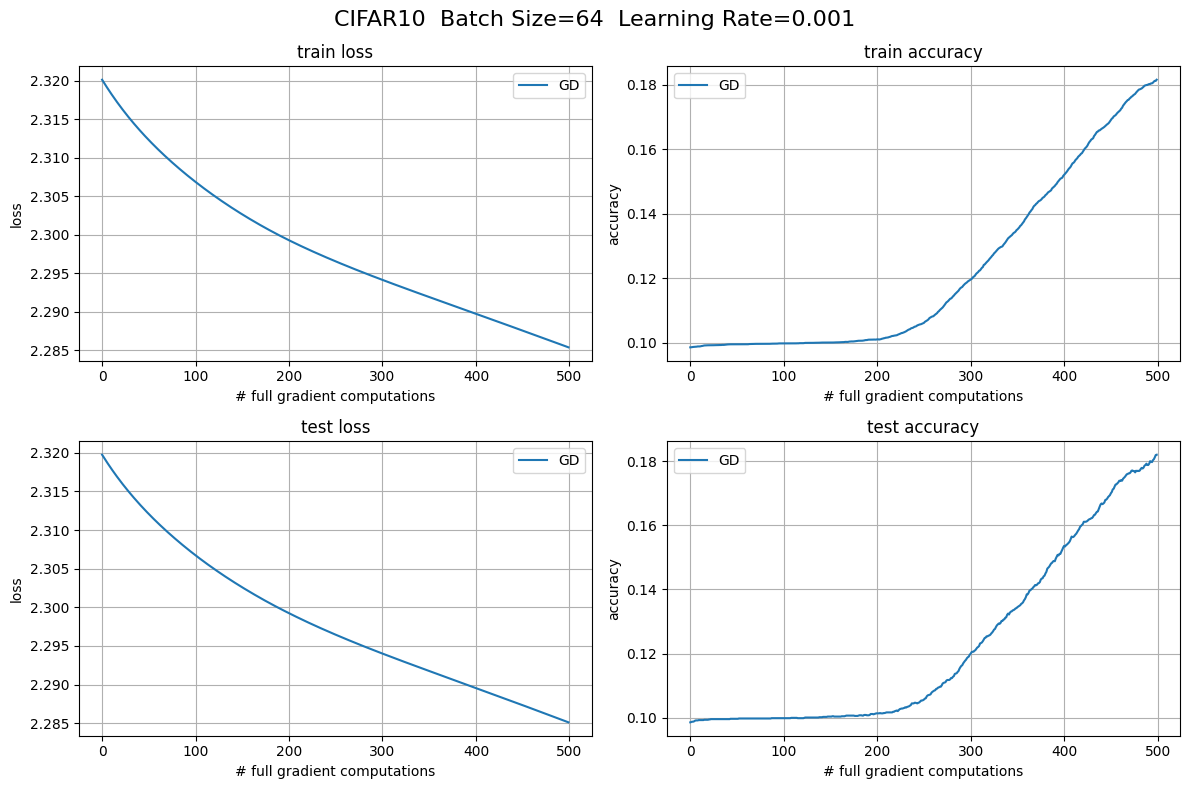

In [15]:
fig = plt.figure(figsize = (12, 8))
fig.suptitle(f"CIFAR10  Batch Size={BATCH_SIZE}  Learning Rate={LEARNING_RATE}",fontsize=16)
ax = fig.add_subplot(2, 2, 1)
#ax.plot(SGD_train_loss_history, label = "SGD")
#ax.plot(SVRG_train_loss_history, label = "SVRG")
#ax.plot(NFG_SVRG_train_loss_history, label = "No Full Grad SVRG")
#ax.plot(ASAI_SVRG_train_loss_history, label = "Polyak-SVRG", linewidth = 3)
ax.plot(GD_train_loss_history, label = "GD")

ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 2)
#ax.plot(SGD_train_acc_history, label = "SGD")
#ax.plot(SVRG_train_acc_history, label = "SVRG")
#ax.plot(NFG_SVRG_train_acc_history, label = "No Full Grad SVRG")
#ax.plot(ASAI_SVRG_train_acc_history, label = "Polyak-SVRG", linewidth = 3)
ax.plot(GD_train_acc_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("train accuracy")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 3)
#ax.plot(SGD_test_loss_history, label = "SGD")
#ax.plot(SVRG_test_loss_history, label = "SVRG")
#ax.plot(NFG_SVRG_test_loss_history, label = "No Full Grad SVRG")
#ax.plot(ASAI_SVRG_test_loss_history, label = "Polyak-SVRG", linewidth = 3)
ax.plot(GD_test_loss_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 4)
#ax.plot(SGD_test_acc_history, label = "SGD")
#ax.plot(SVRG_test_acc_history, label = "SVRG")
#ax.plot(NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
#ax.plot(ASAI_SVRG_test_acc_history, label = "Polyak-SVRG", linewidth = 3)
ax.plot(GD_test_acc_history, label = "GD")
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()